In [154]:

#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

In [155]:
# Load & Combine Datasets
file1 = "../Dataset/plant_disease_data_1.csv"
file2 = "../Dataset/plant_data_2.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print(df1.head())
print(df2.head())


     Plant_ID Plant_Type Leaf_Color  Leaf_Spot_Size  Humidity  Temperature  \
0  PLANT_0001       Corn      Brown            3.80     69.49        30.68   
1  PLANT_0002     Potato      Brown            6.96     45.72        34.57   
2  PLANT_0003       Corn     Yellow            3.08     86.21        29.29   
3  PLANT_0004       Rice     Yellow            0.50     87.46        16.71   
4  PLANT_0005       Rice      Green            1.58     43.38        26.23   

     Disease_Status  
0    Mild Infection  
1    Mild Infection  
2           Healthy  
3           Healthy  
4  Severe Infection  
   Plant_ID Plant_Type  Leaf_Color  Leaf_Spot_Size  Humidity  Temperature  \
0      3000     Pepper       Green            5.97     50.09        35.15   
1      3001     Potato   Yellowish            3.34     45.50        28.10   
2      3002   Cucumber   Yellowish            8.32     41.13        39.34   
3      3003     Potato  Dark Green            3.04     50.00        22.03   
4      3004   

In [156]:

df = pd.concat([df1, df2], ignore_index=True)

df = df[df["Disease_Status"].notna()]
df = df.reset_index(drop=True)

print("Dataset shape after combining:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nSummary Stats:")
print(df.describe())

# Correlation (numeric features only)
numeric_cols = ["Leaf_Spot_Size", "Humidity", "Temperature"]
print("\nCorrelation Matrix:")
print(df[numeric_cols].corr())


Dataset shape after combining: (5500, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Plant_ID        5500 non-null   object 
 1   Plant_Type      5500 non-null   object 
 2   Leaf_Color      5500 non-null   object 
 3   Leaf_Spot_Size  5500 non-null   float64
 4   Humidity        5500 non-null   float64
 5   Temperature     5500 non-null   float64
 6   Disease_Status  5500 non-null   object 
dtypes: float64(3), object(4)
memory usage: 300.9+ KB
None

Summary Stats:
       Leaf_Spot_Size     Humidity  Temperature
count     5500.000000  5500.000000  5500.000000
mean         4.934864    63.737575    27.238258
std          2.875203    17.215488     6.321637
min          0.000000    30.040000    15.000000
25%          2.450000    49.182500    22.020000
50%          4.930000    63.840000    27.150000
75%          7.400000 

/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1301851128.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Plant_Type", palette="Set2", legend=False)


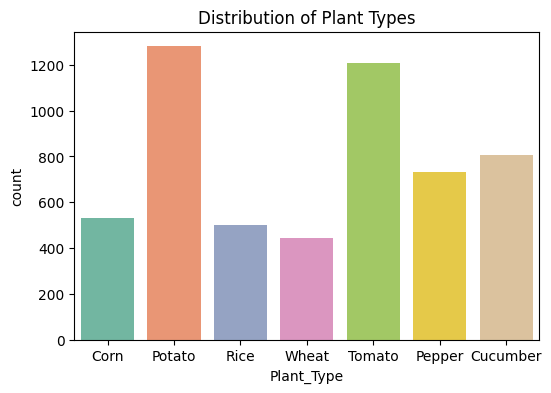

/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1301851128.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Disease_Status", palette="Set1", legend=False)


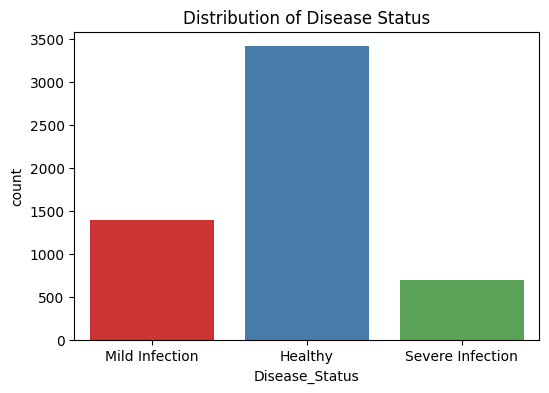

/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1301851128.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Disease_Status", y=col, palette="coolwarm")


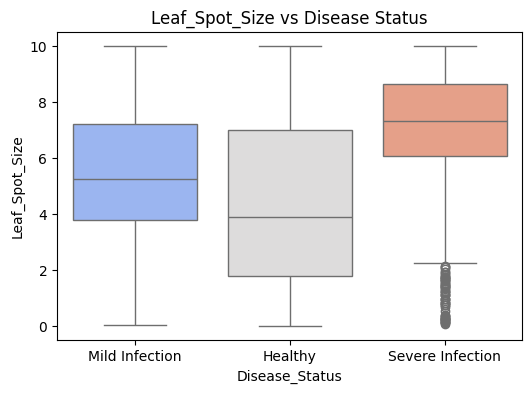

/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1301851128.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Disease_Status", y=col, palette="coolwarm")


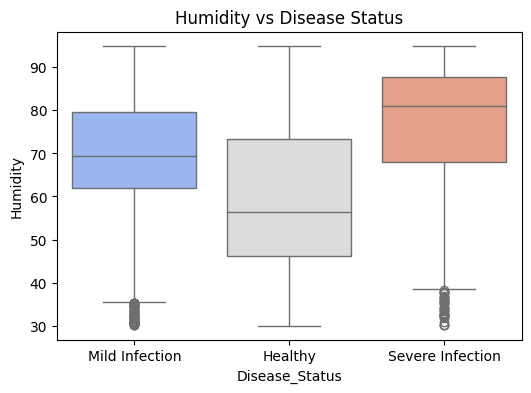

/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1301851128.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Disease_Status", y=col, palette="coolwarm")


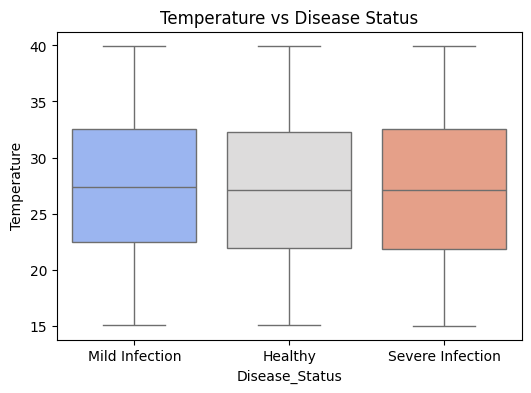

In [157]:
# Exploratory Data Analysis

# Plant Type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Plant_Type", palette="Set2", legend=False)
plt.title("Distribution of Plant Types")
plt.show()

# Disease Status distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Disease_Status", palette="Set1", legend=False)
plt.title("Distribution of Disease Status")
plt.show()

# Boxplots
for col in ["Leaf_Spot_Size", "Humidity", "Temperature"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Disease_Status", y=col, palette="coolwarm")
    plt.title(f"{col} vs Disease Status")
    plt.show()


In [158]:
# Encode Categorical Features
le_plant = LabelEncoder()
le_color = LabelEncoder()
le_status = LabelEncoder()

df["Plant_Type"] = le_plant.fit_transform(df["Plant_Type"])
df["Leaf_Color"] = le_color.fit_transform(df["Leaf_Color"])
df["Disease_Status"] = le_status.fit_transform(df["Disease_Status"])


In [159]:
# Train/Test Split
X = df.drop(["Plant_ID", "Disease_Status"], axis=1)
y = df["Disease_Status"]

# fill missing feature values
X = X.fillna(X.mode().iloc[0])

# encode categorical features
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [160]:
# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Classification Report:
                   precision    recall  f1-score   support

         Healthy       0.82      0.97      0.89       683
  Mild Infection       0.89      0.67      0.76       278
Severe Infection       0.92      0.56      0.70       139

        accuracy                           0.84      1100
       macro avg       0.87      0.73      0.78      1100
    weighted avg       0.85      0.84      0.83      1100



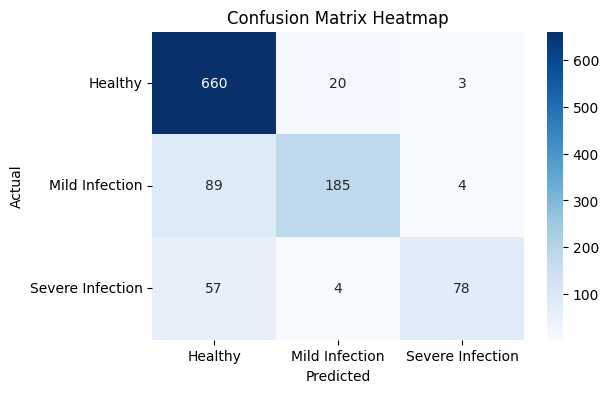

In [161]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Ensure labels present in y_test or y_pred
unique_labels = np.unique(np.concatenate([y_test, y_pred]))

# Convert encoded labels back to original class names
target_names = le_status.inverse_transform(unique_labels)
target_names = [str(name) for name in target_names]   # force to list of strings

# Classification report
print("Classification Report:\n",
      classification_report(y_test, y_pred,
                            labels=unique_labels,
                            target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/1884919453.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


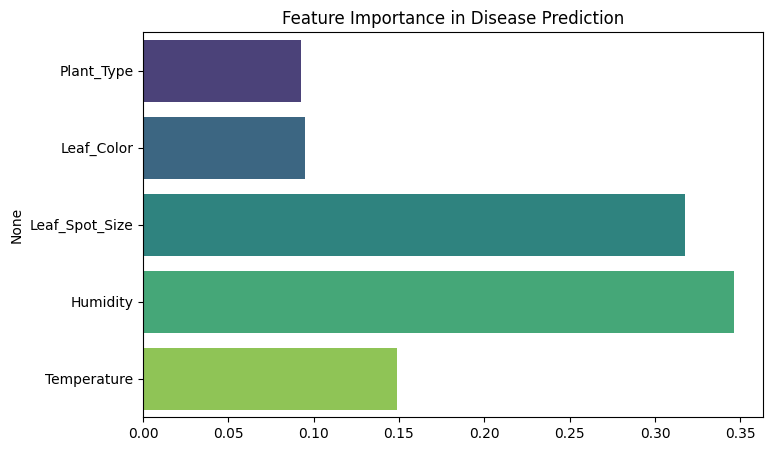

In [162]:
# Feature Importance
plt.figure(figsize=(8,5))
importances = model.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance in Disease Prediction")
plt.show()


In [163]:
# Save Model & Encoders
joblib.dump(model, "plant_disease_model.pkl")
joblib.dump(le_plant, "plant_encoder.pkl")
joblib.dump(le_color, "color_encoder.pkl")
joblib.dump(le_status, "status_encoder.pkl")

print("Model and encoders saved successfully!")


Model and encoders saved successfully!



Feature Importance Scores:
          Feature       Score
3        Humidity  369.935630
2  Leaf_Spot_Size  247.412361
0      Plant_Type    3.269050
4     Temperature    1.406262
1      Leaf_Color    0.690024


/var/folders/vn/j3kyb3f14dngz6y0dp2yf5jh0000gn/T/ipykernel_29818/574663350.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Score", y="Feature", data=feature_scores, palette="crest")


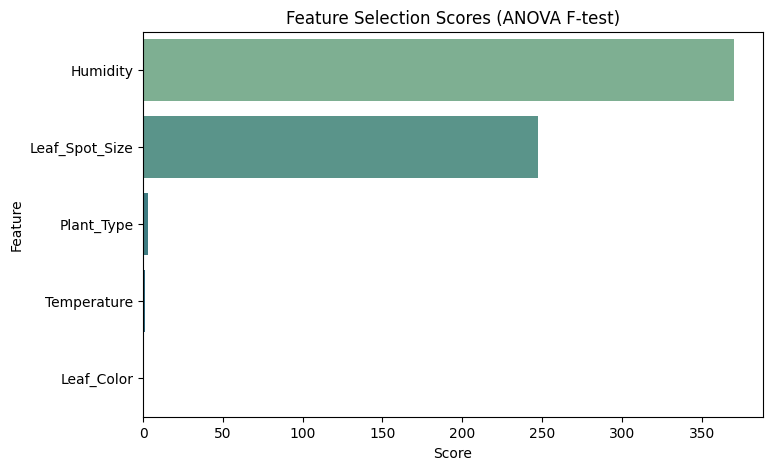

In [164]:
#  Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

X = df.drop(columns=["Plant_ID", "Disease_Status"])
y = df["Disease_Status"]

if y.dtype == "object":
    y = le_status.fit_transform(y)

X_enc = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="mean")
X_enc = pd.DataFrame(imputer.fit_transform(X_enc), columns=X_enc.columns)


selector = SelectKBest(score_func=f_classif, k="all")
X_new = selector.fit_transform(X_enc, y)


feature_scores = pd.DataFrame({
    "Feature": X_enc.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("\nFeature Importance Scores:")
print(feature_scores)


plt.figure(figsize=(8,5))
sns.barplot(x="Score", y="Feature", data=feature_scores, palette="crest")
plt.title("Feature Selection Scores (ANOVA F-test)")
plt.show()

In [165]:
# Cross Validation
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("Cross-validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())


Cross-validation Accuracy Scores: [0.59       0.64       0.94636364 0.98363636 0.98727273]
Mean Accuracy: 0.8294545454545454


In [166]:
# Multi Sample Predictions
import pandas as pd
import numpy as np

# Raw new samples
new_samples_raw = pd.DataFrame({
    "Plant_Type": ["Corn", "Rice", "Potato"],
    "Leaf_Color": ["Green", "Yellow", "Brown"],
    "Leaf_Spot_Size": [1.2, 4.8, 6.0],
    "Humidity": [65.0, 80.0, 50.0],
    "Temperature": [27.0, 30.0, 35.0]
})

X_train_cols = X_train.columns

new_samples_enc = pd.get_dummies(new_samples_raw, drop_first=True)


for col in X_train_cols:
    if col not in new_samples_enc.columns:
        new_samples_enc[col] = 0


new_samples_enc = new_samples_enc[X_train_cols]

probs = model.predict_proba(new_samples_enc)
predictions = model.predict(new_samples_enc)

for i in range(len(new_samples_enc)):
    print(f"Sample {i+1}: {le_status.inverse_transform([predictions[i]])[0]}")
    for cls, p in zip(le_status.classes_, probs[i]):
        print(f"   {cls}: {p:.2f}")


Sample 1: Healthy
   Healthy: 0.79
   Mild Infection: 0.10
   Severe Infection: 0.11
Sample 2: Healthy
   Healthy: 0.72
   Mild Infection: 0.25
   Severe Infection: 0.03
Sample 3: Healthy
   Healthy: 0.57
   Mild Infection: 0.31
   Severe Infection: 0.12


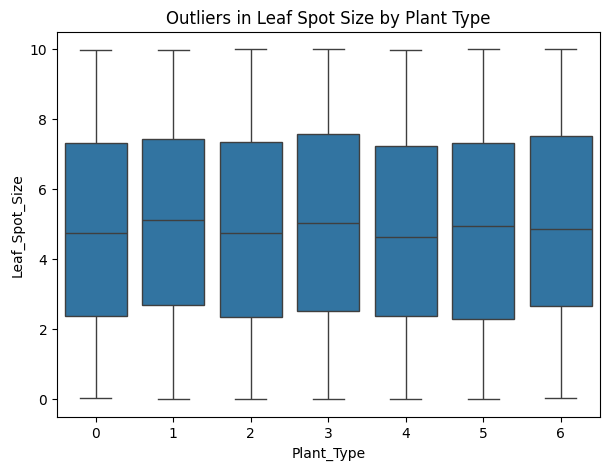

In [167]:
#  Detection
plt.figure(figsize=(7,5))
sns.boxplot(data=df, y="Leaf_Spot_Size", x="Plant_Type")
plt.title("Outliers in Leaf Spot Size by Plant Type")
plt.show()
